# Homework 3

## Magdalena Danielewicz

In [139]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import RocCurveDisplay
roc_curve_est = RocCurveDisplay.from_estimator 
roc_curve_pred = RocCurveDisplay.from_predictions 

## Question 1

#### Suppose we collect data for a group of applicants to a data science bootcamp with variables:
#### • X1 = coding practice hours completed,
#### • X2 = prior programming experience (in years), and
#### • Y = admitted to the bootcamp.
#### We fit a logistic regression and produce estimated coefficients
#### β0 =−4.2,β1 = 0.04, and β2 = 0.8.


#### a. Estimate the probability that an applicant who has completed 60 hours of coding practice and has 2 years of programming experience is admitted to the bootcamp.

-4.2 + 0.04(60) + 0.8(2) - -0.2

e^-0.2 / 1 + e^-0.2 = 0.45  

There's a 45% probability that the applicant is admitted to the bootcamp.


#### b. How many practice hours would the applicant in part (a) need to study to have a 90% chance of being admitted?

0.9 = e^(B0 + B1X1 + B2X2) / 1 + e^(B0 + B1X1 + B2X2)  

log(0.9 / 1 - 0.9) = -4.2 + 0.04X1 + 0.8(2)  

log(9) = 2.197 , so  

2.197 = -4.2 + 0.04X1 + 1.6  

2.197 = -2.6 + 0.04X1  

4.797 = 0.04X1  

X1 = 119.925   

Around 120 hours are needed for the applicant to have a 90% chance to being admitted.  



#### c. Describe in words the meaning of “β0 =−4.2” in the context of this model.

In the context of this model, B0 = -4.2 represents the intercept coefficient. This is the log-odds of admission for the applicant if hours of coding practice are 0 and years of programming experience are 0.

## Question 2

#### Load the OJ data set, which is part of the ISLP library. Details can be found at https://intro-stat-learning.github.io/ISLP/datasets/OJ.html.
#### As a first step, create two subsets of this data:
#### • Train, containing only records with StoreID 1, 2, 3, or 4, and
#### • Test, containing remaining records with StoreID 7.
#### We will use these subsets to predict Citrus Hill purchases.

In [140]:
from ISLP import load_data
OJ = load_data('OJ')

train = OJ[OJ['StoreID'].isin([1, 2, 3, 4])]
test = OJ[OJ['StoreID'] == 7]



#### a. In Train, locate three variables: Citrus Hill loyalty, indication of a Citrus Hill special, and price difference between the brands. Calculate the mean, standard deviation, median, minimum value, and maximum value for each of these variables.

In [141]:
# LoyalCH, SpecialCH, PriceDiff

loyal = train['LoyalCH']
print('LoyalCH Stats:')
print(f'Mean: {loyal.mean()}')
print(f'Standard Deviation: {loyal.std()}')
print(f'Median: {loyal.median()}')
print(f'Minimum: {loyal.min()}')
print(f'Maximum: {loyal.max()}\n')

special = train['SpecialCH']
print('SpecialCH Stats:')
print(f'Mean: {special.mean()}')
print(f'Standard Deviation: {special.std()}')
print(f'Median: {special.median()}')
print(f'Minimum: {special.min()}')
print(f'Maximum: {special.max()}\n')

pricediff = train['PriceDiff'] 
print('PriceDiff Stats:')
print(f'Mean: {pricediff.mean()}')
print(f'Standard Deviation: {pricediff.std()}')
print(f'Median: {pricediff.median()}')
print(f'Minimum: {pricediff.min()}')
print(f'Maximum: {pricediff.max()}')




LoyalCH Stats:
Mean: 0.5199879019607843
Standard Deviation: 0.3137571564198037
Median: 0.5
Minimum: 1.1e-05
Maximum: 0.999947

SpecialCH Stats:
Mean: 0.046218487394957986
Standard Deviation: 0.2101051293520389
Median: 0.0
Minimum: 0
Maximum: 1

PriceDiff Stats:
Mean: 0.11452380952380951
Standard Deviation: 0.2559351252805437
Median: 0.2
Minimum: -0.67
Maximum: 0.44


#### b. Provide a correlation matrix for the three variables in (a).


In [142]:
import pandas as pd

corr_matrix = train.select_dtypes(include='number').corr()

print("\nFull Correlation Matrix:")
print(corr_matrix)

variables = ['LoyalCH', 'SpecialCH', 'PriceDiff']

for var in variables:
    print(f"\nCorrelations with {var}:")
    print(corr_matrix[var].sort_values(ascending=False))



Full Correlation Matrix:
                WeekofPurchase   StoreID   PriceCH   PriceMM    DiscCH  \
WeekofPurchase        1.000000  0.039798  0.699424  0.538580  0.251239   
StoreID               0.039798  1.000000  0.520950  0.229482  0.121816   
PriceCH               0.699424  0.520950  1.000000  0.608199  0.276778   
PriceMM               0.538580  0.229482  0.608199  1.000000 -0.086294   
DiscCH                0.251239  0.121816  0.276778 -0.086294  1.000000   
DiscMM                0.380114 -0.153965  0.202634  0.062640  0.007251   
SpecialCH            -0.064880  0.015104 -0.068728 -0.144215  0.243658   
SpecialMM             0.142871 -0.297075 -0.035175  0.009530 -0.144534   
LoyalCH               0.145285  0.135081  0.108543  0.092089  0.032394   
SalePriceMM          -0.013168  0.263944  0.178482  0.524282 -0.056042   
SalePriceCH           0.570896  0.459902  0.860010  0.658272 -0.252311   
PriceDiff            -0.256620  0.067342 -0.188608  0.242621  0.051662   
PctDiscMM   

#### c. Use the Train subset to perform a logistic regression with Purchase as the response and the three variables from (a) as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?


In [143]:
import statsmodels.api as sm

X_train = train[['LoyalCH', 'SpecialCH', 'PriceDiff']]
Y_train = (train['Purchase'] == 'CH').astype(int)

X_train = sm.add_constant(X_train)  
model = sm.Logit(Y_train, X_train).fit()

print(model.summary())



Optimization terminated successfully.
         Current function value: 0.414155
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Purchase   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                  0.4009
Time:                        21:33:42   Log-Likelihood:                -295.71
converged:                       True   LL-Null:                       -493.55
Covariance Type:            nonrobust   LLR p-value:                 1.902e-85
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4069      0.267    -12.756      0.000      -3.930      -2.883
LoyalCH        6.3847      0.

Yes, the LoyalCH and PriceDiff variables seem to be statistically significant based on their P-values, since they are both 0 < 0.001.

#### d. Using Train and a probability threshold of 0.5, compute the confusion matrix and overall fraction of correct predictions. Also note the percent of false positives and the percent of false negatives.

In [144]:
import numpy as np
from sklearn.metrics import confusion_matrix

probability = model.predict(X_train)
classes = (probability >= 0.5)
Y_train = (train['Purchase'] == 'CH')

matrix = confusion_matrix(Y_train, classes)
print(f'Confusion Matrix:\n{matrix}\n')

fraction = np.mean(classes == Y_train)
print(f'Fraction of correct predictions: {fraction}')

tn = matrix[0, 0]
tp = matrix[1, 1]
fn = matrix[1, 0]
fp = matrix[0, 1]

false_positives = fp / (fp + tn)
false_negatives = fn / (fn + tp)

print(f'Percent of False Positives: {false_positives * 100:.2f}%')
print(f'Percent of False Negatives: {false_negatives * 100:.2f}%')


Confusion Matrix:
[[269  66]
 [ 62 317]]

Fraction of correct predictions: 0.8207282913165266
Percent of False Positives: 19.70%
Percent of False Negatives: 16.36%


#### e. Now refit the logistic regression model on the Train data with only the significant predictors. For this model, use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.


In [145]:
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import confusion_matrix

X_train = train[['LoyalCH', 'PriceDiff']]
Y_train = (train['Purchase'] == 'CH').astype(int)

X_train = sm.add_constant(X_train)  
model = sm.Logit(Y_train, X_train).fit()

print(model.summary())


# second part: using test for matrix eval
X_test = test[['LoyalCH', 'PriceDiff']]
X_test = sm.add_constant(X_test)
Y_test = (test['Purchase'] == 'CH')

probability = model.predict(X_test)
classes = (probability >= 0.5)

matrix = confusion_matrix(Y_test, classes)
print(f'\nConfusion Matrix:\n{matrix}\n')

fraction = np.mean(classes == Y_test)
print(f'Fraction of correct predictions: {fraction}')

tn = matrix[0, 0]
tp = matrix[1, 1]
fn = matrix[1, 0]
fp = matrix[0, 1]

false_positives = fp / (fp + tn)
false_negatives = fn / (fn + tp)

print(f'Percent of False Positives: {false_positives * 100:.2f}%')
print(f'Percent of False Negatives: {false_negatives * 100:.2f}%')



Optimization terminated successfully.
         Current function value: 0.414274
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Purchase   No. Observations:                  714
Model:                          Logit   Df Residuals:                      711
Method:                           MLE   Df Model:                            2
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                  0.4007
Time:                        21:33:42   Log-Likelihood:                -295.79
converged:                       True   LL-Null:                       -493.55
Covariance Type:            nonrobust   LLR p-value:                 1.301e-86
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4159      0.266    -12.820      0.000      -3.938      -2.894
LoyalCH        6.3811      0.

#### f. Use Naive Bayes on the Train data with only the significant predictors from (e). Use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.


In [146]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import numpy as np
from ISLP import load_data

X_train = train[['LoyalCH', 'PriceDiff']]
Y_train = (train['Purchase'] == 'CH').astype(int)

X_test = test[['LoyalCH', 'PriceDiff']]
Y_test = (test['Purchase'] == 'CH').astype(int)

nb = GaussianNB()
nb.fit(X_train, Y_train)
y_prediction = nb.predict(X_test)

cm = confusion_matrix(Y_test, y_prediction)
print(f"\nConfusion Matrix:\n{cm}\n")

tn, fp, fn, tp = cm.ravel()

fraction = np.mean(y_prediction == Y_test)
print(f'Fraction of correct predictions: {fraction}')

false_positives = fp / (fp + tn)
false_negatives = fn / (fn + tp)

print(f'Percent of False Positives: {false_positives * 100:.2f}%')
print(f'Percent of False Negatives: {false_negatives * 100:.2f}%')


Confusion Matrix:
[[ 64  18]
 [ 39 235]]

Fraction of correct predictions: 0.8398876404494382
Percent of False Positives: 21.95%
Percent of False Negatives: 14.23%


#### g.  Build three k-Nearest Neighbors models on the Train data, using k = 5,50,150, and only the significant predictors from (e). For the k = 50 model, use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.


In [147]:
from matplotlib.pyplot import subplots
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay

roc_curve_est = RocCurveDisplay.from_estimator 
roc_curve_pred = RocCurveDisplay.from_predictions 

X_train_knn = train[['LoyalCH', 'PriceDiff']]
Y_train_knn = (train['Purchase'] == 'CH').astype(int)

X_test_knn = test[['LoyalCH', 'PriceDiff']]
Y_test_knn = (test['Purchase'] == 'CH').astype(int)

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_knn, Y_train_knn)



knn50 = KNeighborsClassifier(n_neighbors=50)
knn50.fit(X_train_knn, Y_train_knn)
knn50_pred = knn50.predict(X_test_knn)
cm_knn50 = confusion_matrix(Y_test_knn, knn50_pred)
print(f'Confusion Matrix (k=50):\n')
print(cm_knn50)
print('\n')
fraction = np.mean(knn50_pred == Y_test_knn)
print(f'Fraction of correct predictions: {fraction:.4f}')

tn, fp, fn, tp = cm_knn50.ravel()
false_pos = fp / (fp + tn)
false_neg = fn / (fn + tp)

print(f'Percent of False Positives: {false_pos * 100:.2f}%')
print(f'Percent of False Negatives: {false_neg * 100:.2f}%')

knn150 = KNeighborsClassifier(n_neighbors=150)
knn150.fit(X_train_knn, Y_train)
print('\n')



Confusion Matrix (k=50):

[[ 63  19]
 [ 42 232]]


Fraction of correct predictions: 0.8287
Percent of False Positives: 23.17%
Percent of False Negatives: 15.33%




#### h.  Provide a ROC curve for each of the five models in parts (e), (f), and (g) on the same plot. Which model yields the highest AUC?

AUC scores:
Logistic Regression: 0.8971
Naive Bayes: 0.8903
kNN (k=5): 0.8275
kNN (k=50): 0.8968
kNN (k=150): 0.8940


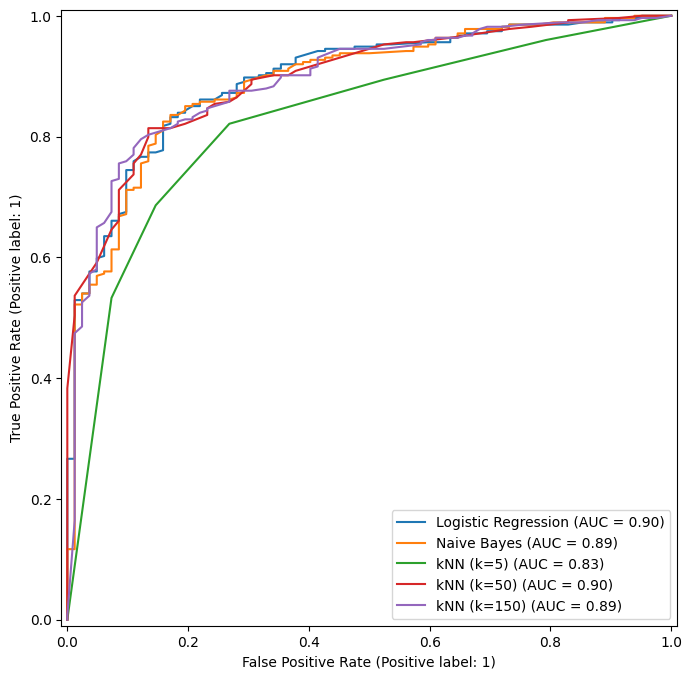

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


X_train = train[['LoyalCH', 'PriceDiff']]
Y_train = (train['Purchase'] == 'CH').astype(int)

X_test = test[['LoyalCH', 'PriceDiff']]
Y_test = (test['Purchase'] == 'CH').astype(int)

fig, ax = plt.subplots(figsize=(8, 8))

# logistic
log_reg = LogisticRegression()
log_reg.fit(X_train, Y_train)
RocCurveDisplay.from_estimator(log_reg, X_test, Y_test, name='Logistic Regression', ax=ax)
auc_log = roc_auc_score(Y_test, log_reg.predict_proba(X_test)[:, 1])

# naive
nb = GaussianNB()
nb.fit(X_train, Y_train)
RocCurveDisplay.from_estimator(nb, X_test, Y_test, name='Naive Bayes', ax=ax)
auc_nb = roc_auc_score(Y_test, nb.predict_proba(X_test)[:, 1])

# knn
knn5 = KNeighborsClassifier(n_neighbors=5)
knn50 = KNeighborsClassifier(n_neighbors=50)
knn150 = KNeighborsClassifier(n_neighbors=150)

for k, model in zip([5, 50, 150], [knn5, knn50, knn150]):
    model.fit(X_train, Y_train)
    RocCurveDisplay.from_estimator(model, X_test, Y_test, name=f'kNN (k={k})', ax=ax)


# auc
auc_knn5 = roc_auc_score(Y_test, knn5.predict_proba(X_test)[:, 1])
auc_knn50 = roc_auc_score(Y_test, knn50.predict_proba(X_test)[:, 1])
auc_knn150 = roc_auc_score(Y_test, knn150.predict_proba(X_test)[:, 1])

print("AUC scores:")
print(f"Logistic Regression: {auc_log:.4f}")
print(f"Naive Bayes: {auc_nb:.4f}")
print(f"kNN (k=5): {auc_knn5:.4f}")
print(f"kNN (k=50): {auc_knn50:.4f}")
print(f"kNN (k=150): {auc_knn150:.4f}")


## Question 3

#### In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n= 6 observations and p= 2 features. The observations are as follows:
Obs. X1   X2  
1    1    4  
2    1    3   
3    0    4  
4    5    1  
5    6    2  
6    4    0  

#### a. Plot the observations using a single color for all data points.


In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.preprocessing import StandardScaler
from ISLP import load_data


from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

Text(0, 0.5, 'X2')

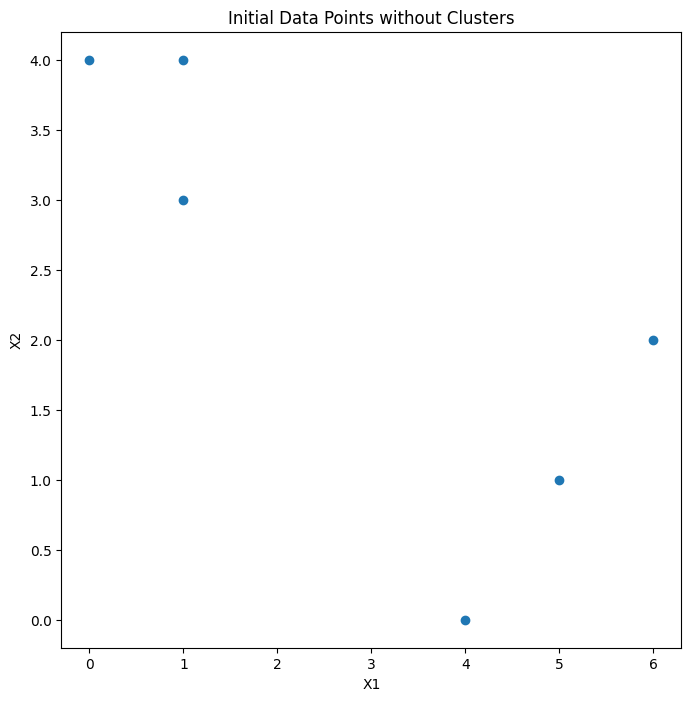

In [150]:
# K = 2, n = 6, p = 2
obs = [1, 2, 3, 4, 5, 6]
X1 = [1, 1, 0, 5, 6, 4]
X2 = [4, 3, 4, 1, 2, 0]

fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X1, X2)
ax.set_title("Initial Data Points without Clusters")
ax.set_xlabel('X1')
ax.set_ylabel('X2')



#### b. Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.


In [151]:
np.random.seed(10)

labels = np.random.choice([1, 2], size=6)
data = pd.DataFrame(
    {'Obs.' : obs,
     'X1': X1, 
     'X2': X2, 
     'Cluster': labels})

print(data)


   Obs.  X1  X2  Cluster
0     1   1   4        2
1     2   1   3        2
2     3   0   4        1
3     4   5   1        2
4     5   6   2        1
5     6   4   0        2


#### c. Compute the centroid for each cluster.


In [152]:
# Compute the centroid for each cluster.

centroids = data.groupby('Cluster')[['X1', 'X2']].mean()
print('\nCentroids:')
print(centroids)


Centroids:
           X1   X2
Cluster           
1        3.00  3.0
2        2.75  2.0


#### d. Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.


In [153]:
centroid1 = centroids.values[0]
centroid2 = centroids.values[1]

dist1 = np.sqrt((X1 - centroid1[0])**2 + (X2 - centroid1[1])**2)
dist2 = np.sqrt((X1 - centroid2[0])**2 + (X2 - centroid2[1])**2)

clusters = np.where(dist1 < dist2, 1, 2)

data = pd.DataFrame({'X1': X1, 'X2': X2, 'Cluster': clusters})
print(data)


   X1  X2  Cluster
0   1   4        1
1   1   3        1
2   0   4        1
3   5   1        2
4   6   2        1
5   4   0        2


#### e. Repeat (c) and (d) until the answers obtained stop changing.


In [154]:
# First Try
centroids = data.groupby('Cluster')[['X1', 'X2']].mean()
print('\nCentroids:\n')
print(centroids)

centroid1 = centroids.values[0]
centroid2 = centroids.values[1]

dist1 = np.sqrt((X1 - centroid1[0])**2 + (X2 - centroid1[1])**2)
dist2 = np.sqrt((X1 - centroid2[0])**2 + (X2 - centroid2[1])**2)

clusters = np.where(dist1 < dist2, 1, 2)

data = pd.DataFrame({'X1': X1, 'X2': X2, 'Cluster': clusters})
print(f'\n{data}')



Centroids:

          X1    X2
Cluster           
1        2.0  3.25
2        4.5  0.50

   X1  X2  Cluster
0   1   4        1
1   1   3        1
2   0   4        1
3   5   1        2
4   6   2        2
5   4   0        2


In [155]:
# Second Try
centroids = data.groupby('Cluster')[['X1', 'X2']].mean()
print('\nCentroids:\n')
print(centroids)

centroid1 = centroids.values[0]
centroid2 = centroids.values[1]

dist1 = np.sqrt((X1 - centroid1[0])**2 + (X2 - centroid1[1])**2)
dist2 = np.sqrt((X1 - centroid2[0])**2 + (X2 - centroid2[1])**2)

clusters = np.where(dist1 < dist2, 1, 2)

data = pd.DataFrame({'X1': X1, 'X2': X2, 'Cluster': clusters})
print(f'\n{data}')

print('\nClusters stopped changing after two iterations.')



Centroids:

               X1        X2
Cluster                    
1        0.666667  3.666667
2        5.000000  1.000000

   X1  X2  Cluster
0   1   4        1
1   1   3        1
2   0   4        1
3   5   1        2
4   6   2        2
5   4   0        2

Clusters stopped changing after two iterations.


#### f. In your plot from (a), color the observations according to the cluster labels obtained.

Text(0, 0.5, 'X2')

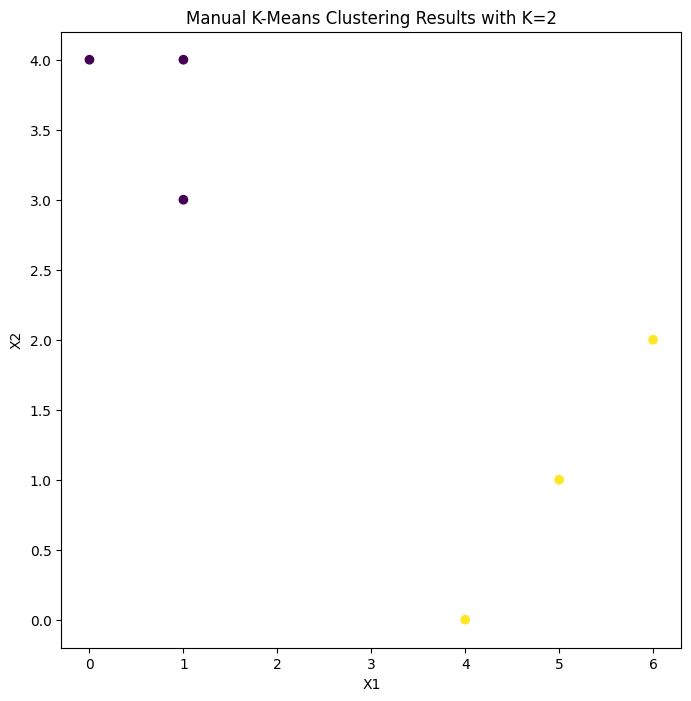

In [156]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X1, X2, c=clusters)
ax.set_title("Manual K-Means Clustering Results with K=2")
ax.set_xlabel('X1')
ax.set_ylabel('X2')

## Question 4

#### Adapted from ISLP 12.6.9. Load the CEV2021 data set, which is available on HuskyCT. Source data and details can be found at https://data.americorps.gov (search “CEV findings: state”).

In [157]:
import pandas as pd

cev = pd.read_csv('CEV2021.csv')

#### a. Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states. Report your answer with a dendrogram.


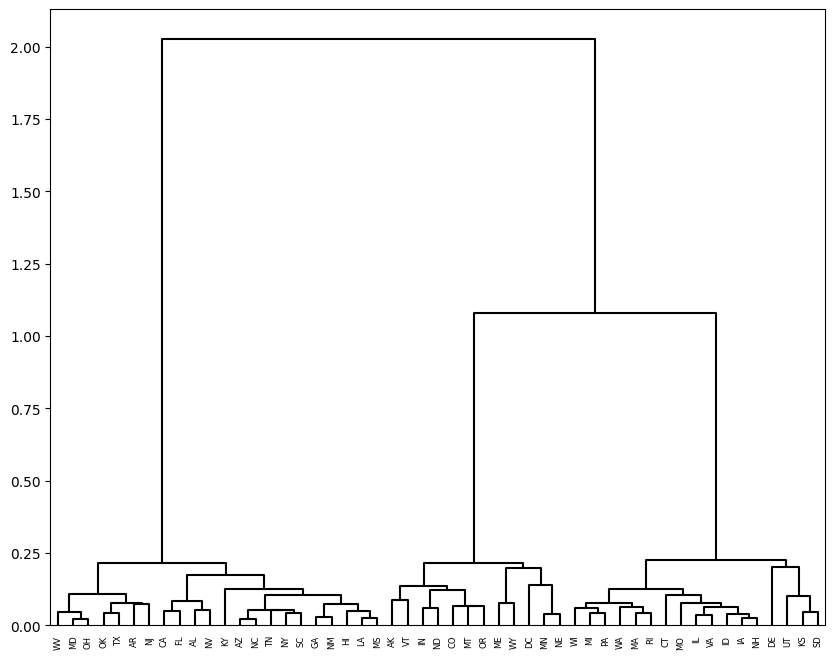

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from ISLP.cluster import compute_linkage

cev_numeric = cev.select_dtypes(include='number')


HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete',
                 metric='euclidean')
hc_comp.fit(cev_numeric)

linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
den = dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=cev['State'].values,
           color_threshold=-np.inf,
           above_threshold_color='black')

plt.show()


#### b. Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?



Cluster 0:
AL, AZ, CA, FL, GA, HI, KY, LA, MS, NV, NM, NY, NC, SC, TN

Cluster 1:
AK, CO, DC, IN, KS, ME, MN, MT, NE, ND, OR, SD, UT, VT, WY

Cluster 2:
AR, CT, DE, ID, IL, IA, MD, MA, MI, MO, NH, NJ, OH, OK, PA, RI, TX, VA, WA, WV, WI


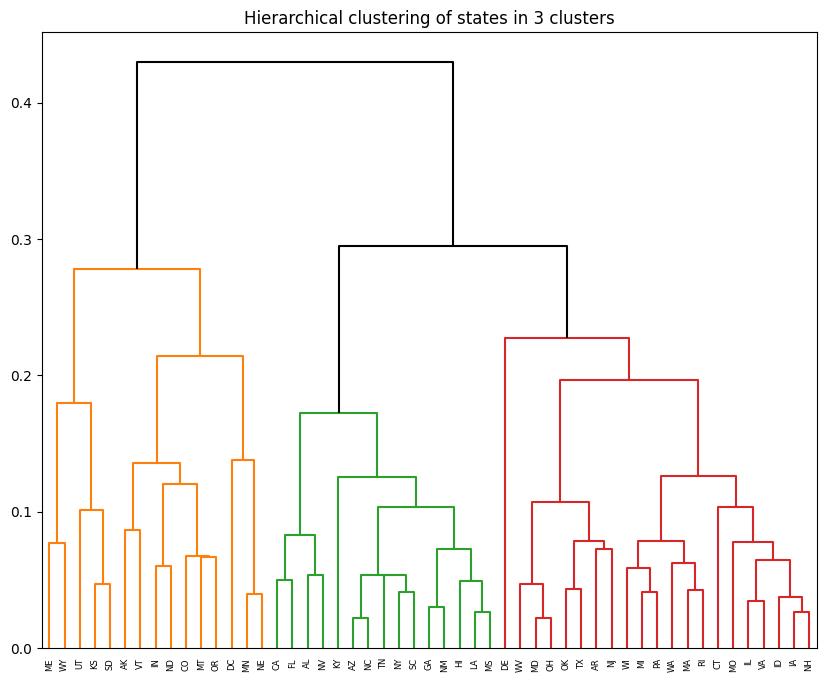

In [159]:
from scipy.cluster.hierarchy import cut_tree
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree

cev['Cluster'] = cut_tree(linkage_comp, n_clusters=3)

for num, group in cev.groupby('Cluster'):
    print(f"\nCluster {num}:")
    print(", ".join(group['State'].values))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
den = dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=cev['State'].values,
           color_threshold=linkage_comp[-2, 2], 
           above_threshold_color='black')
ax.set_title("Hierarchical clustering of states in 3 clusters")
plt.show()


#### c. Cut the dendrogram at a height that results in four distinct clusters. Which states belong to which clusters?



Cluster 0:
AL, AZ, AR, CA, FL, GA, HI, KY, LA, MD, MS, NV, NJ, NM, NY, NC, OH, OK, SC, TN, TX, WV

Cluster 1:
AK, CO, DC, IN, ME, MN, MT, NE, ND, OR, VT, WY

Cluster 2:
CT, ID, IL, IA, MA, MI, MO, NH, PA, RI, VA, WA, WI

Cluster 3:
DE, KS, SD, UT


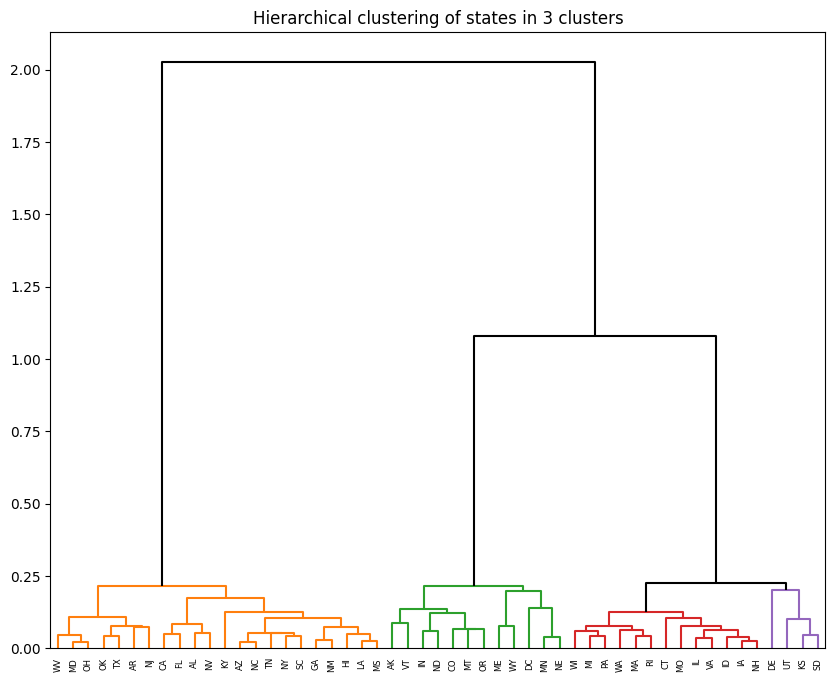

In [168]:
from scipy.cluster.hierarchy import cut_tree
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree

cev['Cluster'] = cut_tree(linkage_comp, n_clusters=4)

for num, group in cev.groupby('Cluster'):
    print(f"\nCluster {num}:")
    print(", ".join(group['State'].values))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
den = dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=cev['State'].values,
           color_threshold=linkage_comp[-3, 2], 
           above_threshold_color='black')
ax.set_title("Hierarchical clustering of states in 3 clusters")
plt.show()

#### d. Use K-means clustering and K = 3 to obtain new clusters of states. Which states belong to which clusters?


In [161]:
from sklearn.cluster import KMeans

cev_numeric = cev.select_dtypes(include='number')

kmeans = KMeans(n_clusters=3, random_state=1, n_init=1)

kmeans.fit(cev_numeric)

cluster_km = pd.DataFrame({
    'State': cev['State'],
    'Cluster': kmeans.labels_
})

for i in range(3):
    print(f"Cluster {i}:")
    states = cluster_km.loc[cluster_km['Cluster'] == i, 'State'].tolist()
    print(", ".join(states))
    print()

    

Cluster 0:
AR, CT, DE, ID, IL, IA, KS, ME, MD, MA, MI, MO, NH, NJ, OH, OK, PA, RI, SD, TX, UT, VA, WA, WV, WI, WY

Cluster 1:
AL, AZ, CA, FL, GA, HI, KY, LA, MS, NV, NM, NY, NC, SC, TN

Cluster 2:
AK, CO, DC, IN, MN, MT, NE, ND, OR, VT



#### e. Repeat part (a), but first rescale and replace your variables so that they have mean 0 and standard deviation 1 (i.e., perform the clustering on the z-scores of the features, rather than the features themselves). Provide the new dendrogram.


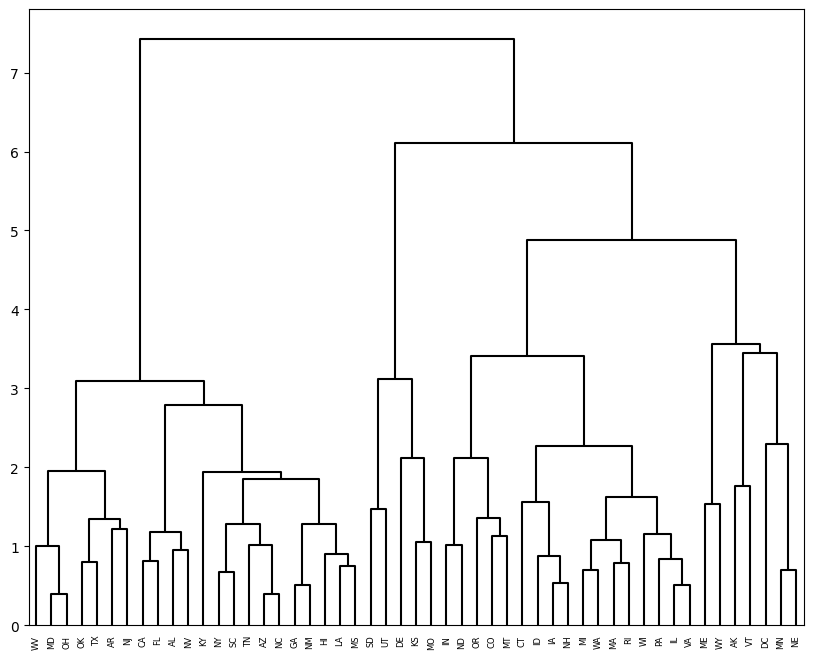

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from ISLP.cluster import compute_linkage

cev_numeric = cev.select_dtypes(include='number')

scaler = StandardScaler()
cev_scale = scaler.fit_transform(cev_numeric)

HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete',
                 metric='euclidean')
hc_comp.fit(cev_scale)

linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
den = dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=cev['State'].values,
           color_threshold=-np.inf,
           above_threshold_color='black')

plt.show()

#### f. Cut the new dendrogram from part (e) at a height that results in three distinct clusters. Which states belong to which clusters?



Cluster 0:
AL, AZ, AR, CA, FL, GA, HI, KY, LA, MD, MS, NV, NJ, NM, NY, NC, OH, OK, SC, TN, TX, WV

Cluster 1:
AK, CO, DC, IN, ME, MN, MT, NE, ND, OR, VT, WY

Cluster 2:
CT, DE, ID, IL, IA, KS, MA, MI, MO, NH, PA, RI, SD, UT, VA, WA, WI


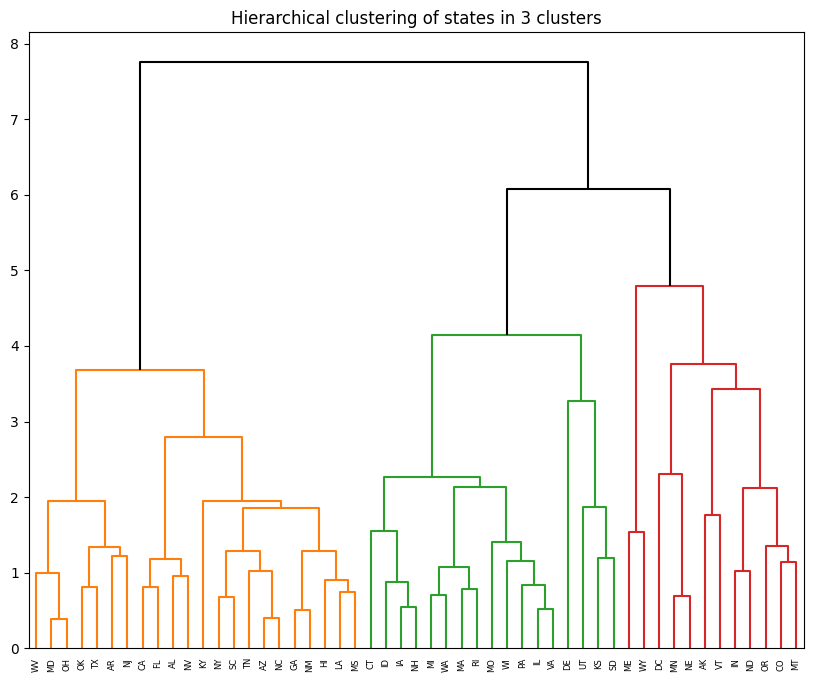

In [163]:
from scipy.cluster.hierarchy import cut_tree
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree

cev['Cluster'] = cut_tree(linkage_comp, n_clusters=3)

for num, group in cev.groupby('Cluster'):
    print(f"\nCluster {num}:")
    print(", ".join(group['State'].values))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=cev['State'].values,
           color_threshold=linkage_comp[-2, 2], 
           above_threshold_color='black')
ax.set_title("Hierarchical clustering of states in 3 clusters")
plt.show()


#### g. Using the z-scores created in part (e), use K-means clustering and K = 3 to obtain new clusters of states. Which states belong to which clusters?


In [164]:
from sklearn.cluster import KMeans

cev_numeric = cev.select_dtypes(include='number')

kmeans = KMeans(n_clusters=3,
                random_state=1,
                n_init=1).fit(cev_scale)

cluster_km = pd.DataFrame({ 
    'State': cev['State'],
    'Cluster': kmeans.labels_ 
    })
cluster_km.index=cev.index

for i in range(3):
    print(f"Cluster {i}:")
    states = cluster_km.loc[cluster_km['Cluster'] == i, 'State'].tolist()
    print(", ".join(states))
    print()


Cluster 0:
AR, CT, DE, ID, IL, IN, IA, KS, MD, MA, MI, MO, NH, NJ, OH, OK, PA, RI, SD, TX, VA, WA, WV, WI

Cluster 1:
AL, AZ, CA, FL, GA, HI, KY, LA, MS, NV, NM, NY, NC, SC, TN

Cluster 2:
AK, CO, DC, ME, MN, MT, NE, ND, OR, UT, VT, WY



#### h. Create a scatter plot of the states with axes Voting Local and Organization Membership which assigns a color to each point based on the clusters found in part (g).

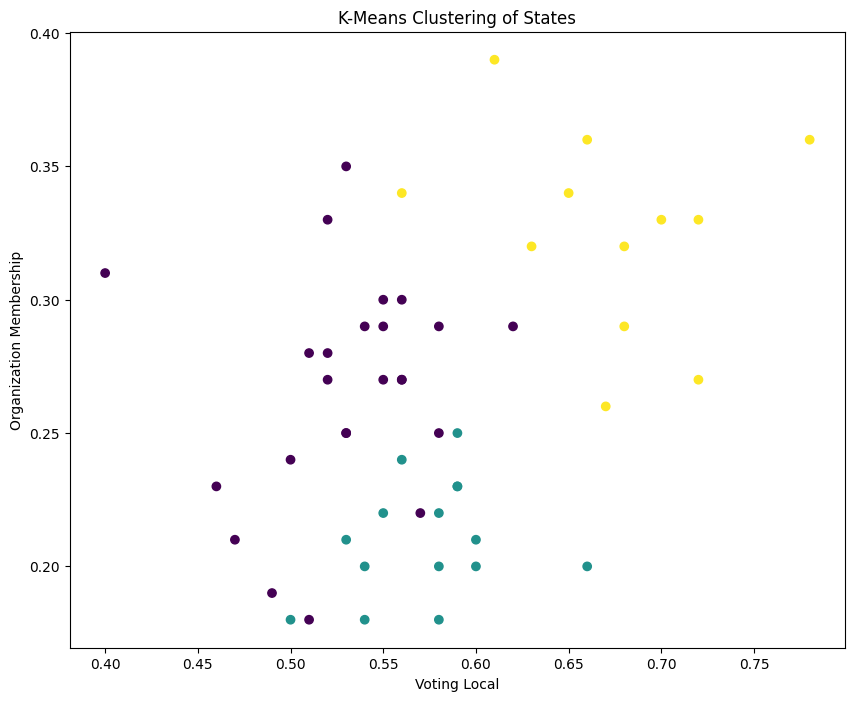

In [165]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
scatter = plt.scatter(cev_numeric['Voting_Local'],
                      cev_numeric['Organizational_Membership'],
                      c=kmeans.labels_,
                      cmap='viridis')
plt.xlabel('Voting Local')
plt.ylabel('Organization Membership')
plt.title('K-Means Clustering of States')
plt.show()